In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [7]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw
from colossus.halo import concentration
from colossus.halo import profile_einasto
from colossus.halo import profile_diemer23

conc = 4
z0 =1.5
cosmo = cosmology.setCosmology('planck15')

p_nfw = profile_nfw.NFWProfile(M = 1e13, c = conc, z = 1.5, mdef = 'vir')
p_einasto = profile_einasto.EinastoProfile(M = 1e13, c = conc, z = 1.5, mdef = 'vir')


bin_edges = np.logspace(1, 4, 10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


rho_nfw = p_nfw.density(bin_centers)
rho_einasto = p_einasto.density(bin_centers)

In [49]:
from colossus.halo import mass_so

R_pkpc_h = mass_so.M_to_R(1E13, 1.5, 'vir')
rvir = pkpc_2_cmpc(R_pkpc_h)
print(rvir)

0.5265809877822862


In [105]:
def pkpc_2_cmpc(r, z=1.5):
    # original is pkpc/h
    # I want to convert to cMpc/h

    r_kpc_h = r*(1+z)
    r_mpc_h = r_kpc_h / 1e3

    return r_mpc_h

In [106]:
def cmpc_2_pkpc(r_cmpc_h, z=1.5):
    # original is pkpc/h
    # I want to convert to cMpc/h

    r_kpc_h = r_cmpc_h * 1e3

    #print(r_kpc_h)

    r_pkpc_h = r_kpc_h/(1+z)
    

    return r_pkpc_h

In [107]:
def convert_rho_units(rho, z=1.5):
    # rho is in units of Msun h^2 / pkpc^3
    # (Msun / h) / (pkpc/h)^3

    rho_mpc_h = rho/((1+z)/1e3)**3

    return rho_mpc_h



[]

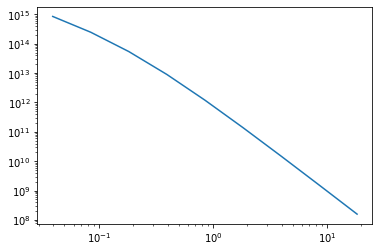

In [29]:
plt.plot(convert_len_units(bin_centers), convert_rho_units(rho_nfw))
#plt.plot(bin_centers, rho_einasto)

plt.loglog()

[]

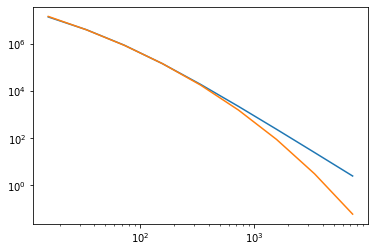

In [11]:
plt.plot(bin_centers, rho_nfw)
plt.plot(bin_centers, rho_einasto)

plt.loglog()

In [51]:
r1 = cmpc_2_pkpc(rvir)
print(r1)
m_enc_nfw = p_nfw.enclosedMass(r1)
print(np.log10(m_enc_nfw))

526.5809877822862
210.63239511291448
13.0


In [134]:
def nfw_ft_numerical_from_colossus(k_values, mvir, conc, rmax, z=1.5):


    p_nfw = profile_nfw.NFWProfile(M = mvir, c = conc, z = z, mdef = 'vir')

    #R_pkpc_h = mass_so.M_to_R(mvir, z=z, mdef='vir')
    #rvir = pkpc_2_cmpc(R_pkpc_h)

    #rmax_pkpc_h = cmpc_2_pkpc(rmax) 

    def rho(r):
        rho1 = p_nfw.density(r)
        rho1 = convert_rho_units(rho1)
        return rho1


    def integrand_func(r_cmpc_h):
        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) * np.sin(k * r_cmpc_h) / (k * r_cmpc_h)
        return integrand

    def integrand_norm(r_cmpc_h):

        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) 
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [135]:
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [166]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks

In [176]:
uk_colossus = nfw_ft_numerical_from_colossus(ks, mvir=1e13, conc=4, rmax=1.5)

In [146]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos
#rvir = 0.5
rvir = pkpc_2_cmpc(R_pkpc_h)
c = 4
r_s = rvir/c
print(r_s)
rho0 = rho_s(10**13, r_s, c)
print(rho0)

0.13164524694557156
430914435864654.06


In [178]:
uk_numerical = nfw_ft_numerical(ks, rho0, r_s,rvir, rmax=2)

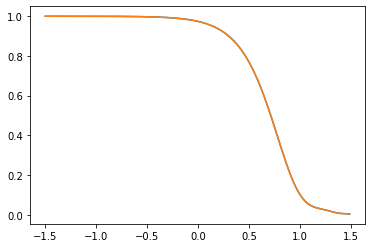

In [148]:
plt.plot(logks, uk_numerical**2)
plt.plot(logks, uk_colossus**2)

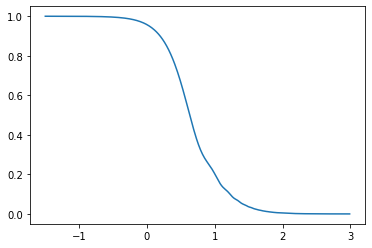

In [157]:
plt.plot(logks, uk_numerical)
#plt.plot(logks, uk_colossus)

In [158]:
def einasto_ft_numerical_from_colossus(k_values, mvir, conc, rmax, z=1.5):
    p_einasto = profile_einasto.EinastoProfile(M = mvir, c = conc, z = z, mdef = 'vir')

    #R_pkpc_h = mass_so.M_to_R(mvir, z=z, mdef='vir')
    #rvir = pkpc_2_cmpc(R_pkpc_h)

    #rmax_pkpc_h = cmpc_2_pkpc(rmax) 

    def rho(r):
        rho1 = p_einasto.density(r)
        rho1 = convert_rho_units(rho1)
        return rho1


    def integrand_func(r_cmpc_h):
        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) * np.sin(k * r_cmpc_h) / (k * r_cmpc_h)
        return integrand

    def integrand_norm(r_cmpc_h):

        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) 
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [179]:
uk_einasto = einasto_ft_numerical_from_colossus(ks, mvir=1e13, conc=4, rmax=2)

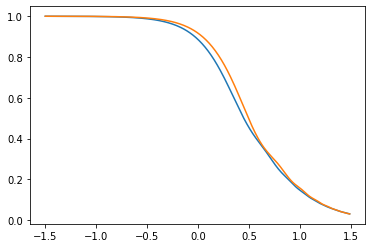

In [180]:
plt.plot(logks, uk_einasto)
plt.plot(logks, uk_colossus)